In [1]:
from datamodel import TradingState, Listing, OrderDepth, Observation, Symbol, Trade, Position, Order
from backtester import Backtester
from typing import Dict, List
from trader import Trader
import matplotlib.pyplot as plt
from visualizer import BacktestingResult
import numpy as np
import json

In [2]:
from data_parser import clean_df, get_group_prices, group_to_trades
from research_tools import get_options_df, implied_vol_bisection
import pandas as pd
import matplotlib.pyplot as plt

prices_files = []
trades_files = []
round = 5
for i in range(2, 5):
    prices_files.append("./data/round_5_data/prices_round_"+str(round)+"_day_"+str(i)+".csv")
    trades_files.append("./data/round_5_data/trades_round_"+str(round)+"_day_"+str(i)+".csv")
df=get_group_prices(prices_files)

In [7]:
df.head(10)

,index,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,0,2,0,PEBBLES_L,9994,13,9992,21,0,0,10006,13,10008,21,0,0,10000.0,0.0
1,1,2,0,SNACKPACK_RASPBERRY,9992,36,9990,45,0,0,10008,36,10010,45,0,0,10000.0,0.0
2,2,2,0,UV_VISOR_RED,9994,22,9992,26,0,0,10006,22,10008,26,0,0,10000.0,0.0
3,3,2,0,PEBBLES_M,9994,13,9992,21,0,0,10006,13,10008,21,0,0,10000.0,0.0
4,4,2,0,GALAXY_SOUNDS_DARK_MATTER,9994,22,9992,26,0,0,10006,22,10008,26,0,0,10000.0,0.0
5,5,2,0,UV_VISOR_ORANGE,9994,22,9992,26,0,0,10006,22,10008,26,0,0,10000.0,0.0
6,6,2,0,PEBBLES_S,9994,13,9992,21,0,0,10006,13,10008,21,0,0,10000.0,0.0
7,7,2,0,UV_VISOR_YELLOW,9994,22,9992,26,0,0,10006,22,10008,26,0,0,10000.0,0.0
8,8,2,0,MICROCHIP_TRIANGLE,9996,5,9995,9,0,0,10004,5,10005,9,0,0,10000.0,0.0
9,9,2,0,MICROCHIP_SQUARE,9996,5,9995,9,0,0,10004,5,10005,9,0,0,10000.0,0.0


In [5]:
trades = group_to_trades(trades_files, 1000000)

c:\Projects\IMC_PROSPERITY_4\backtesting_engine\data_parser.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("", 0)
c:\Projects\IMC_PROSPERITY_4\backtesting_engine\data_parser.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["buyer"].replace(0, "", inplace=True)
c:\Project

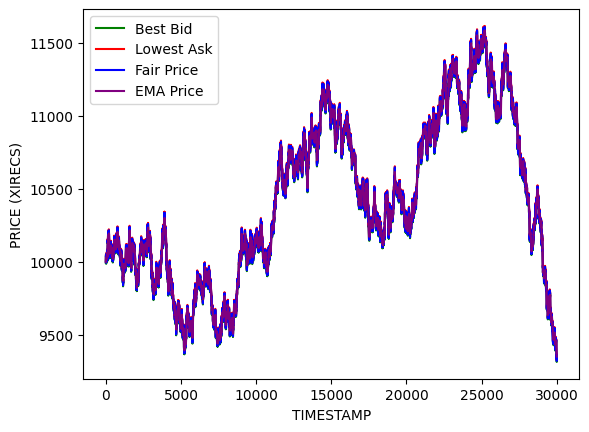

In [81]:
#view specific product

def ema(prices, alpha=0.1):
    trend = None
    out = []

    for p in prices:
        if trend is None:
            trend = p
        else:
            trend = alpha * p + (1 - alpha) * trend

        out.append(trend)

    return np.array(out)

SYMBOL = "UV_VISOR_ORANGE"

extract_bid_price = df.loc[df['product']==SYMBOL]["bid_price_1"].to_numpy()
extract_ask_price = df.loc[df['product']==SYMBOL]["ask_price_1"].to_numpy()
extract_mid_price = df.loc[df['product']==SYMBOL]["mid_price"].to_numpy().astype(float)

window = 100
mp_ema = ema(extract_mid_price)

plt.plot([i for i in range(len(extract_bid_price))], extract_bid_price, color="green", label="Best Bid")
plt.plot([i for i in range(len(extract_bid_price))], extract_ask_price, color="red", label="Lowest Ask")
plt.plot([i for i in range(len(extract_bid_price))], extract_mid_price, color="blue", label="Fair Price")
plt.plot([i for i in range(len(extract_bid_price))], mp_ema, color="purple", label="EMA Price")
plt.legend()
plt.xlabel("TIMESTAMP")
plt.ylabel("PRICE (XIRECS)")
plt.show()

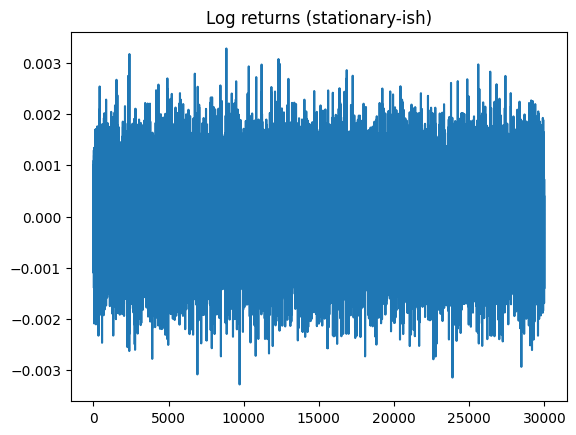

In [5]:
mid = extract_mid_price.astype(float)

# Option A: simple returns (differences)
ret = np.diff(mid)          # length N-1

# Option B: log returns (better behaved)
log_mid = np.log(mid)
log_ret = np.diff(log_mid)

plt.plot(log_ret)
plt.title("Log returns (stationary-ish)")
plt.show()

In [9]:
log_ret.std()

np.float64(0.0008031292581286599)

In [101]:
def kalman_trend_mean_reverting(prices,
                               process_var=1e-6,
                               measurement_var=25.0,
                               kappa=0.05):  # mean reversion speed

    n = 50

    # State: [trend, residual]
    x = np.array([prices[0], 0.0])
    P = np.eye(2)

    # Transition
    F = np.array([
        [1, 0],
        [0, (1 - kappa)]   # residual mean reverts
    ])

    # Observation: price = trend + residual
    H = np.array([[1, 1]])

    Q = np.array([
        [process_var, 0],
        [0, process_var]
    ])

    R = np.array([[measurement_var]])

    trend = []
    residuals = []

    for z in prices:
        # Predict
        x = F @ x
        P = F @ P @ F.T + Q

        # Update
        y = np.array([z]) - H @ x
        S = H @ P @ H.T + R
        K = P @ H.T @ np.linalg.inv(S)

        x = x + (K @ y).flatten()
        P = (np.eye(2) - K @ H) @ P

        trend.append(x[0])
        residuals.append(x[1])

    return np.array(trend), np.array(residuals)

def decaying_midrange(prices, alpha=0.001):
    max_est = None
    min_est = None
    out = []

    for p in prices:
        if max_est is None:
            max_est = p
            min_est = p
        else:
            # decay previous extremes toward current price
            max_est = max(p, (1 - alpha) * max_est + alpha * p)
            min_est = min(p, (1 - alpha) * min_est + alpha * p)

        mid = (max_est + min_est) / 2
        out.append(mid)

    return np.array(out)

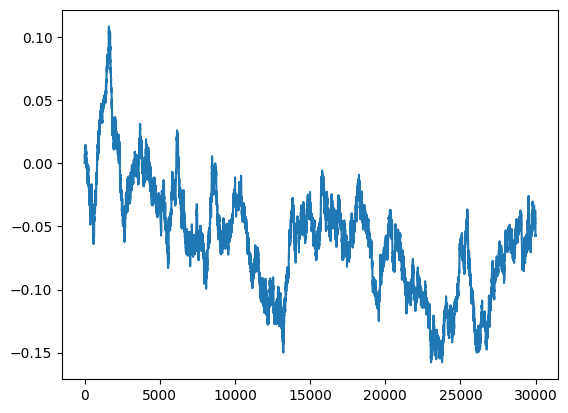

In [23]:
strawberry_mp = df.loc[df['product']=="SNACKPACK_RASPBERRY"]["mid_price"].to_numpy().astype(float)
raspberry_mp = df.loc[df['product']=="SNACKPACK_STRAWBERRY"]["mid_price"].to_numpy().astype(float)
beta = np.cov(strawberry_mp, raspberry_mp)[0,1] / np.var(raspberry_mp)
spread_diff = np.log(strawberry_mp)  - np.log(raspberry_mp)
# Rolling mean of the spread


#midrange_line = decaying_midrange(spread_diff, alpha=0.0001)
#plt.plot(midrange_line, color="black", linewidth=2, label="Kalman Trend")
# Rolling std (optional)

plt.plot(spread_diff)
plt.show()

In [7]:
beta

np.float64(0.30346616240568314)

In [4]:
spread_diff.mean()

np.float64(7059.56356065088)

In [5]:
spread_diff.std()

np.float64(586.2765778666098)

In [9]:
spread_diff.std()

np.float64(675.2297095501123)

In [7]:
from statsmodels.tsa.stattools import adfuller

spread = spread_diff  # your spread
result = adfuller(spread, autolag='AIC')
adf_stat, p_value = result[0], result[1]

print("ADF stat:", adf_stat)
print("p-value:", p_value)

ADF stat: -2.3769810816196335
p-value: 0.14833899794039673


In [62]:
rolling_std.mean()

np.float64(34.38110117766363)

In [53]:
spread_diff.std() 

np.float64(757.1291364427691)

In [54]:
import numpy as np
import statsmodels.api as sm
S = spread_diff
S_lag = S[:-1]
dS = S[1:] - S[:-1]

# Regression: dS = alpha + beta * S_lag + error
X = sm.add_constant(S_lag)
model = sm.OLS(dS, X).fit()

alpha = model.params[0]
beta = model.params[1]

# OU parameters
theta = -np.log(1 + beta)
mu = alpha / theta
sigma = np.std(model.resid) * np.sqrt(2 * theta / (1 - (1 + beta)**2))

# Half-life
half_life = np.log(2) / theta

print("alpha:", alpha)
print("beta:", beta)
print("theta:", theta)
print("mu:", mu)
print("sigma:", sigma)
print("half-life:", half_life)

alpha: 0.08178598023691605
beta: -0.0003283553975514354
theta: 0.00032840931798863444
mu: 249.0367226417933
sigma: 21.211754220847055
half-life: 2110.6197132443535


In [10]:
print("Mean spread: " + str(np.mean(extract_ask_price-extract_bid_price)))

Mean spread: 15.925633333333334


In [105]:
import json
from datamodel import OrderDepth, TradingState, Order
from typing import Dict, List
from statistics import NormalDist
import numpy as np
arr=[]
class Trader:
    def __init__(self):
        # all product groups
        self.GALAXY_SOUNDS_RECORDERS = [
            "GALAXY_SOUNDS_DARK_MATTER",
            "GALAXY_SOUNDS_BLACK_HOLES",
            "GALAXY_SOUNDS_PLANETARY_RINGS",
            "GALAXY_SOUNDS_SOLAR_WINDS",
            "GALAXY_SOUNDS_SOLAR_FLAMES"
        ]
        self.VERTICAL_SLEEPING_PODS = [
            "SLEEP_POD_SUEDE",
            "SLEEP_POD_LAMB_WOOL",
            "SLEEP_POD_POLYESTER",
            "SLEEP_POD_NYLON",
            "SLEEP_POD_COTTON"
        ]
        self.ORGANIC_MICROCHIPS = [
            "MICROCHIP_CIRCLE",
            "MICROCHIP_OVAL",
            "MICROCHIP_SQUARE",
            "MICROCHIP_RECTANGLE",
            "MICROCHIP_TRIANGLE"
        ]
        self.PURIFICATION_PEBBLES = [
            "PEBBLES_XS",
            "PEBBLES_S",
            "PEBBLES_M",
            "PEBBLES_L",
            "PEBBLES_XL"
        ]
        self.DOMESTIC_ROBOTS = [
            "ROBOT_VACUUMING",
            "ROBOT_MOPPING",
            "ROBOT_DISHES",
            "ROBOT_LAUNDRY",
            "ROBOT_IRONING"
        ]
        self.UV_VISORS = [
            "UV_VISOR_YELLOW",
            "UV_VISOR_AMBER",
            "UV_VISOR_ORANGE",
            "UV_VISOR_RED",
            "UV_VISOR_MAGENTA"
        ]
        self.INSTANT_TRANSLATORS = [
            "TRANSLATOR_SPACE_GRAY",
            "TRANSLATOR_ASTRO_BLACK",
            "TRANSLATOR_ECLIPSE_CHARCOAL",
            "TRANSLATOR_GRAPHITE_MIST",
            "TRANSLATOR_VOID_BLUE"
        ]
        self.CONSTRUCTION_PANELS = [
            "PANEL_1X2",
            "PANEL_2X2",
            "PANEL_1X4",
            "PANEL_2X4",
            "PANEL_4X4"
        ]
        self.LIQUID_BREATH_OXYGEN_SHAKES = [
            "OXYGEN_SHAKE_MORNING_BREATH",
            "OXYGEN_SHAKE_EVENING_BREATH",
            "OXYGEN_SHAKE_MINT",
            "OXYGEN_SHAKE_CHOCOLATE",
            "OXYGEN_SHAKE_GARLIC"
        ]
        self.PROTEIN_SNACK_PACKS = [
            "SNACKPACK_CHOCOLATE",
            "SNACKPACK_VANILLA",
            "SNACKPACK_PISTACHIO",
            "SNACKPACK_STRAWBERRY",
            "SNACKPACK_RASPBERRY"
        ]
    
    def execute_mm_strat(self, state: TradingState):
        symbols = ["MICROCHIP_CIRCLE", "MICROCHIP_OVAL", "TRANSLATOR_ASTRO_BLACK", "TRANSLATOR_GRAPHITE_MIST", "TRANSLATOR_VOID_BLUE", "SLEEP_POD_COTTON", "SLEEP_POD_SUEDE", "UV_VISOR_RED", "UV_VISOR_ORANGE"]
        LIMIT = 10
        for symbol in symbols:
            orders=[]
            best_bid = max(state.order_depths[symbol].buy_orders)
            best_ask = min(state.order_depths[symbol].sell_orders)
            position = state.position.get(symbol, 0)
            mid_p = (best_bid+best_ask)/2
            bid_quote = best_bid + 1
            ask_quote = best_ask - 1

            # Skewing
            if position > 5:
                ask_quote -= 1
            elif position < -5:
                bid_quote += 1
            buy_qty  = LIMIT - position
            sell_qty = LIMIT + position

            if buy_qty > 0:
                orders.append(Order(symbol, bid_quote, buy_qty))
            if sell_qty > 0:
                orders.append(Order(symbol, ask_quote, -sell_qty))

            self.result[symbol] = orders
    
    def execute_stat_arb_strat(self, state: TradingState, mean: float, std: float, symbol_1: str, symbol_2:str, k: int = 1, b:float = 1):
        LIMIT = 10
        best_bid_1 = max(state.order_depths[symbol_1].buy_orders)
        best_ask_1 = min(state.order_depths[symbol_1].sell_orders)
        position_1 = state.position.get(symbol_1, 0)
        mid_p_1 = (best_bid_1+best_ask_1)/2
        
        best_bid_2 = max(state.order_depths[symbol_2].buy_orders)
        best_ask_2 = min(state.order_depths[symbol_2].sell_orders)
        position_2 = state.position.get(symbol_2, 0)
        mid_p_2 = (best_bid_2+best_ask_2)/2
        
        spread_diff = mid_p_1- b * mid_p_2
        short_t = mean+ (std*k)
        long_t = mean - (std*k)

        if spread_diff >= short_t: #shorting symbol 1, longing symbol 2
            #print ("AQ")
            sell_qty  = LIMIT + position_1
            buy_qty = LIMIT - position_2
            self.result[symbol_1].append(Order(symbol_1, best_bid_1, -sell_qty))
            self.result[symbol_2].append(Order(symbol_2, best_ask_2, buy_qty))
        elif spread_diff <= long_t: #long symbol 1, short symbol 2
            sell_qty  = LIMIT + position_2 
            buy_qty = LIMIT - position_1
            self.result[symbol_2].append(Order(symbol_2, best_bid_2, -sell_qty))
            self.result[symbol_1].append(Order(symbol_1, best_ask_1, buy_qty))
    def mean_rev(self, state: TradingState, symbol_1: str, mean: float, std: float, k:int = 1):
        LIMIT = 10
        best_bid_1 = max(state.order_depths[symbol_1].buy_orders)
        best_ask_1 = min(state.order_depths[symbol_1].sell_orders)
        position_1 = state.position.get(symbol_1, 0)
        mid_p_1 = (best_bid_1+best_ask_1)/2

        if symbol_1 not in self.trader_state:
            self.trader_state[symbol_1] = np.log(mid_p_1)
            return
        
        buy_qty  = LIMIT - position_1
        sell_qty = LIMIT + position_1

        f_p = np.log(mid_p_1)-self.trader_state[symbol_1]
        short_t = mean+ (std*k)
        long_t = mean - (std*k)
        if f_p >= short_t: #shorting symbol 1, longing symbol 2
            self.result[symbol_1].append(Order(symbol_1, best_bid_1, -sell_qty))
        elif f_p <= long_t: #long symbol 1, short symbol 2
            self.result[symbol_1].append(Order(symbol_1, best_ask_1, buy_qty))

        self.trader_state[symbol_1] = np.log(mid_p_1)

    def reset(self, state: TradingState):
        self.result = {}
        for symbol in state.order_depths:
            self.result[symbol] = []

    def run(self, state: TradingState):
        self.reset(state)
        if state.traderData and state.traderData != "":
            self.trader_state = json.loads(state.traderData)
        else:
            self.trader_state = {}
        #self.execute_mm_strat(state)
        #self.mean_rev(state, "SNACKPACK_RASPBERRY", 9.869443899015643e-07, 0.0008031292581286599, 3.5)
        self.execute_stat_arb_strat(state, 381.84, 658.125, "TRANSLATOR_ECLIPSE_CHARCOAL", "TRANSLATOR_SPACE_GRAY", k=1)
        self.execute_stat_arb_strat(state, 7059.56356065088, 586.2765778666098, "PEBBLES_L", "PEBBLES_M", b=0.30346616240568314)
        return self.result, 0, json.dumps(self.trader_state)

In [11]:
backtesting_engine = Backtester(prices_files, trades_files)

c:\Projects\IMC_PROSPERITY_4\backtesting_engine\data_parser.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("", 0)
c:\Projects\IMC_PROSPERITY_4\backtesting_engine\data_parser.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["buyer"].replace(0, "", inplace=True)
c:\Project

In [106]:
sample_trader = Trader()
#backtesting_engine.custom_shifter["TOMATOES"]=1.5
backtesting_result = backtesting_engine.run_trader(sample_trader, enable_probabilistic_fills=False, enable_market_trades=True)

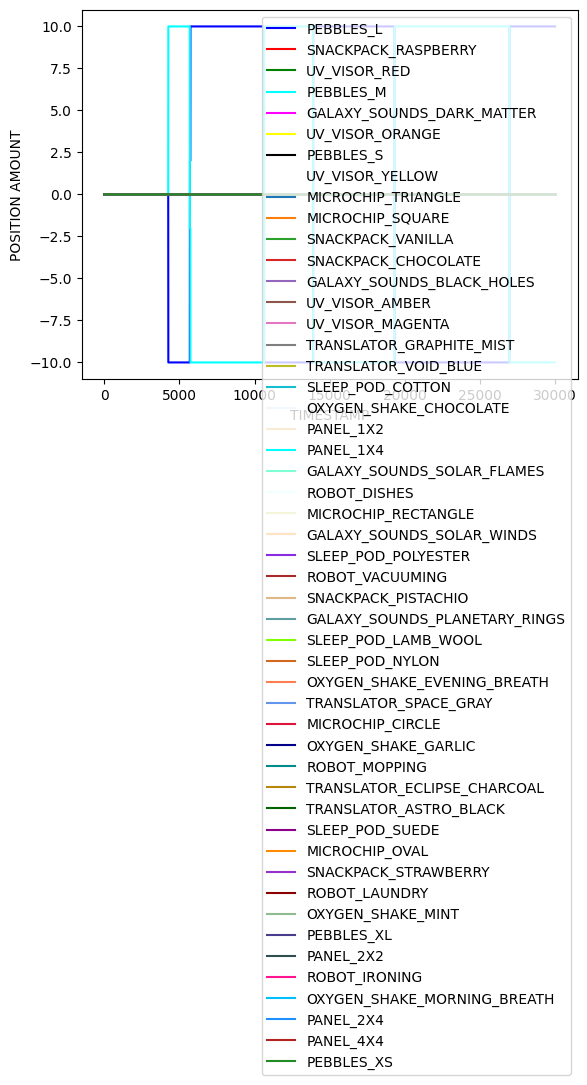

In [102]:
backtesting_result.graph_inventory()

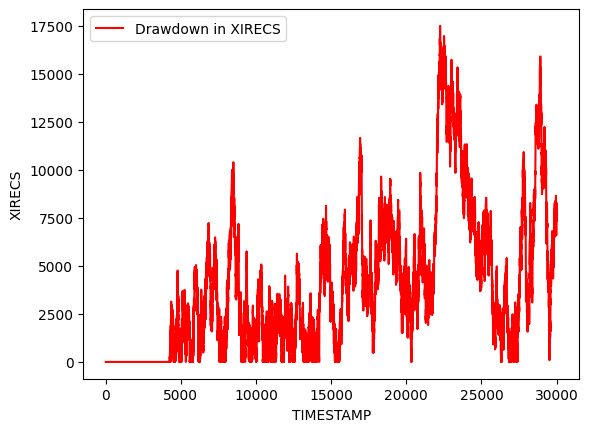

In [103]:
backtesting_result.graph_drawdown()

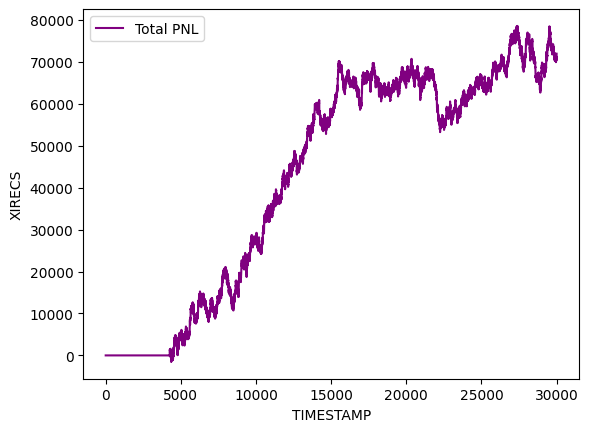

In [104]:
backtesting_result.graph_pnl()